# 15 — Language

Grounding words in pixels, a tiny vision-language-action model, and an
agent that checks its work · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/15-language/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** This week renders
    thousands of camera pictures through EGL, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains one small network on the CPU, about a minute.

## “Look at the green one.”

Four balls float in front of the G1. A person says a sentence. The robot
has to work out **which** ball the words mean, **where** it is in the
picture, and **what to do** about it — and then make sure it did.

That is the whole of Layer 5 in miniature: *what should the robot
achieve?*, asked in the language people actually use.

1.  Words become numbers; pixels become numbers; **attention** matches
    them.
2.  A 20,000-parameter vision-language-action model, trained in a
    minute.
3.  What it understood, and what it only appeared to.
4.  An **agent**: a sentence → a plan of skills → physics → a check
    after every step.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from soc4180 import vision
from soc4180.render import _new_renderer

torch.manual_seed(0); torch.set_num_threads(4)
NAMES = ("red", "green", "blue", "yellow")
model = vision.camera_model(NAMES, radius=0.15)
print(f"{model.nmocap} balls: {', '.join(NAMES)}; one camera in the head")

4 balls: red, green, blue, yellow; one camera in the head

------------------------------------------------------------------------

## What a VLA is

**Vision-language-action** models — RT-2 (Google DeepMind, 2023),
OpenVLA (2024), π0 (Physical Intelligence, 2024) — take a camera picture
and an instruction and output robot actions:

|  | RT-2 / OpenVLA / π0 | today |
|------------------------|------------------------|------------------------|
| vision | a pretrained image transformer | 3 convolutions, trained here |
| language | a pretrained language model, billions of parameters | a bag of 19 words |
| how they meet | cross-attention inside a transformer | **one** attention step |
| action | tokens or a flow over joint commands | *where*, then a skill |
| training data | ~1 million robot episodes + the internet | 3,000 rendered pictures |
| parameters | 3–55 billion | **20,032** |

The shapes are the same. What changes is how much each part knew before
it ever saw a robot — and today we measure exactly what that buys.

------------------------------------------------------------------------

## The world, and its labels

3000 + 600 pictures in 5 s; labels (3000, 4, 2): every ball's (azimuth, elevation)

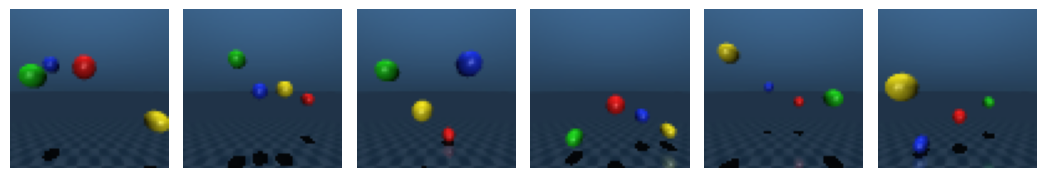

In [2]:
t0 = time.time()
X, Y = vision.render_dataset(model, 3000, seed=0, dist=(1.0, 2.5))
Xtest, Ytest = vision.render_dataset(model, 600, seed=1000, dist=(1.0, 2.5))
print(f"{len(X)} + {len(Xtest)} pictures in {time.time() - t0:.0f} s; labels {Y.shape}: every ball's (azimuth, elevation)")
fig, axes = plt.subplots(1, 6, figsize=(11, 2.1))
for ax, img in zip(axes, X[:6]):
    ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
fig.tight_layout(); plt.show()

The simulator knows where it put all four balls, so every picture comes
with four labels. A sentence picks one of them.

------------------------------------------------------------------------

## Words as numbers

In [3]:
TEMPLATES = ["point at the {c} ball", "look at the {c} one", "{c}", "find the {c} ball",
             "where is the {c} ball", "turn toward the {c} sphere", "show me {c}"]
vocab = vision.Vocab([t.format(c=c) for t in TEMPLATES for c in NAMES])
print(f"{len(vocab)} words: {', '.join(vocab.index)}")
print("bag('look at the green one') =", vocab.bag("look at the green one").int().tolist())
print("bag('the crimson ball')      =", vocab.bag("the crimson ball").int().tolist(), " <- 'crimson' lands in <unk>")

19 words: <unk>, point, at, the, red, ball, green, blue, yellow, look, one, find, where, is, turn, toward, sphere, show, me
bag('look at the green one') = [0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
bag('the crimson ball')      = [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  <- 'crimson' lands in <unk>

A **bag of words**: one slot per known word, counting how often it
appears. Order is lost — “red left of blue” and “blue left of red” are
the same bag — and an unknown word lands in the single `<unk>` slot,
indistinguishable from every other unknown word.

A real VLA replaces this with a language model’s *embedding*: each word
(or piece of one) becomes a vector learned from billions of sentences,
so “crimson” arrives already close to “red”.

------------------------------------------------------------------------

## Pixels as keys, words as a query

``` python
class HeatNet(nn.Module):                                   # soc4180.vision.HeatNet
    def __init__(self, nvocab, channels=32):
        self.keys = nn.Sequential(conv 3->32, relu, conv 32->32 stride 2, relu,
                                  conv 32->channels stride 2)          # 64x64 picture -> 16x16 grid
        self.query = nn.Linear(nvocab, channels)                        # the sentence -> one vector

    def forward(self, images, bags):
        k = self.keys(images).flatten(2)                     # B x C x 256 cells: a key per cell
        q = self.query(bags)                                 # B x C: the query
        return torch.einsum("bcn,bc->bn", k, q) / sqrt(C)    # a score per cell
```

$$\text{score}_{\text{cell}} = \frac{k_{\text{cell}}\cdot q}{\sqrt{C}}, \qquad
\text{heat} = \operatorname{softmax}(\text{score})$$

This is **attention** — the operation a transformer repeats billions of
times — with one query. The picture offers 256 keys (“here is something
greenish and round”), the sentence asks one question (“green?”), and the
dot product says which cells answer it. The $\sqrt C$ keeps the scores
near 1 at the start, so the softmax is not already one-hot before
training.

------------------------------------------------------------------------

## Training: cross-entropy on *where*

In [4]:
net = vision.HeatNet(len(vocab))
opt = torch.optim.Adam(net.parameters(), 2e-3)
rng = np.random.default_rng(0)

def batch(images, labels, templates, r):
    which = r.integers(len(NAMES), size=len(images))                 # one named ball per picture
    said = [templates[r.integers(len(templates))].format(c=NAMES[w]) for w in which]
    bags = torch.stack([vocab.bag(s) for s in said])
    return vision.as_tensor(images), bags, labels[np.arange(len(images)), which], said

t0 = time.time()
for epoch in range(10):
    img, bags, target, _ = batch(X, Y, TEMPLATES, rng)
    cells = torch.as_tensor(vision.cell_of(vision.uv_of(target[:, 0], target[:, 1]), net.grid))
    perm = torch.randperm(len(img))
    for i in range(0, len(img), 64):
        b = perm[i:i + 64]
        loss = torch.nn.functional.cross_entropy(net(img[b], bags[b]), cells[b])   # "which cell?" as classification
        opt.zero_grad(); loss.backward(); opt.step()
print(f"{sum(p.numel() for p in net.parameters()):,} parameters, 10 epochs in {time.time() - t0:.0f} s, "
      f"last loss {loss.item():.2f}")

20,032 parameters, 10 epochs in 28 s, last loss 0.53

*Where* is a classification over 256 cells — the label is the cell the
named ball is in. The answer read out afterwards is the heat map’s
centre of mass, which can land between cells.

------------------------------------------------------------------------

## Four questions, one picture

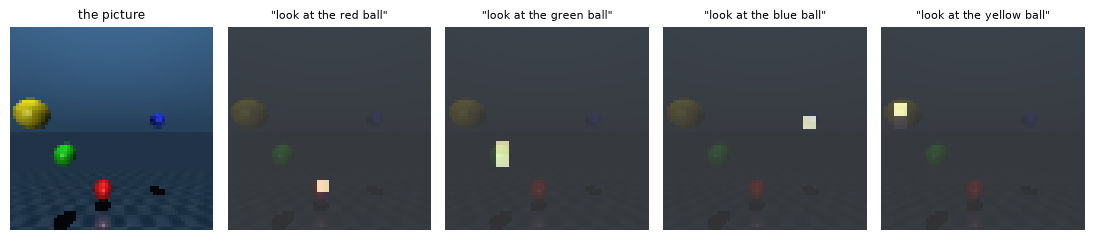

In [5]:
img = Xtest[3]
fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.5))
axes[0].imshow(img.transpose(1, 2, 0)); axes[0].set_title("the picture", fontsize=9); axes[0].axis("off")
for ax, c in zip(axes[1:], NAMES):
    with torch.no_grad():
        heat = torch.softmax(net(vision.as_tensor(img[None]), vocab.bag(f"look at the {c} ball")[None]), -1)
    ax.imshow(img.transpose(1, 2, 0), alpha=0.45)
    ax.imshow(heat.reshape(net.grid, net.grid).numpy(), cmap="magma", alpha=0.65, extent=(-0.5, 63.5, 63.5, -0.5))
    ax.set_title(f'"look at the {c} ball"', fontsize=8); ax.axis("off")
fig.tight_layout(); plt.show()

Same picture, same keys; only the query changes, and the heat moves to a
different ball. Nothing in the network was told what “green” looks like
— it learned it because *green* in the sentence and the cell holding the
green ball kept appearing together.

------------------------------------------------------------------------

## What did it understand?

In [6]:
NEW = ["can you face the {c} ball please", "the {c} one, over there", "go {c}"]
def test(templates, label):
    img, bags, target, said = batch(Xtest, Ytest, templates, np.random.default_rng(5))
    with torch.no_grad():
        ang = vision.angles_of_uv(vision.heat_to_uv(net(img, bags), net.grid))
    e = np.degrees(np.linalg.norm(ang - target, axis=1))
    print(f"{label:32s} {e.mean():6.1f}°  {100 * np.mean(e < 5):5.0f}% within 5°   e.g. \"{said[0]}\"")
test(TEMPLATES, "phrasings it was trained on")
test(NEW, "new phrasings, known colours")
test(["point at the crimson ball"], "a colour word it never saw")
test(["point at the ball"], "no colour word at all")

phrasings it was trained on         2.0°     99% within 5°   e.g. "where is the blue ball"
new phrasings, known colours        2.1°     99% within 5°   e.g. "the blue one, over there"
a colour word it never saw         31.0°      7% within 5°   e.g. "point at the crimson ball"
no colour word at all              31.0°      6% within 5°   e.g. "point at the ball"

New sentences work *perfectly* — “can you face the green ball please”
was never in the data. That looks like understanding, and it is not: in
a bag of words the only informative words are the four colours, so any
sentence that contains one works and every other word is ignored.

A colour word it never saw is **chance** — about 31°, the same as no
colour at all. There is no road from “crimson” to “red” in 3,000
pictures and 19 words. Pretraining on the internet is that road.

------------------------------------------------------------------------

## Confidently wrong

Hide the named ball behind the robot and ask for it anyway. Measured
over 200 pictures, half with the ball in view and half without:

| the named ball is    | heat-map peak, mean | … extreme        |
|----------------------|---------------------|------------------|
| in the picture       | 0.88                | lowest 0.42      |
| **behind the robot** | **0.60**            | **highest 0.98** |

The network was only ever shown pictures in which the ball was present,
so it has no way to say *“not here”*: it points at *something*, often
with full confidence. Its own output cannot be used to check itself.

So the agent checks with a **different, simpler sense**: the raw colour
of the pixels where the network points. If they are not green, whatever
the network believes, it is not looking at the green ball. Week 14 found
the same failure from the other side — the ball that left the picture.

------------------------------------------------------------------------

## From a sentence to a plan

``` python
def parse(instruction, synonyms=None, programs=None):          # soc4180.agent.parse
    text = apply synonyms word by word
    if a known phrase from `programs` is in the text: return its plan
    for clause in split on "and", "then", ",":
        "look/face/turn/point" -> ("look", clause)      "find/search" -> ("search", clause)
        "raise/wave/lift"      -> ("raise", side)  or ("raise_both",) if "both"
        "lower/drop"           -> ("lower", side)       anything else -> ("unknown", clause)
```

Each **skill** runs the physics and then **verifies** with a sensor:

| skill | does | checks |
|------------------------|------------------------|------------------------|
| `look(words)` | turns the waist, HeatNet in the loop (week 14’s servo) | the pixels where it points have that colour; within 5° of centre |
| `search(words)` | look; if the check fails, turn 60°, 60° the other way, 120° … | the same |
| `raise(side)` | shoulder to −150°, elbow straight (week 3’s WAVE) | hand above 1.2 m |
| `raise_both()` | both shoulders at once | hands above 1.2 m |
| every skill |  | pelvis above 0.6 m, tilt under 20° |

------------------------------------------------------------------------

## An agent, running

In [7]:
from soc4180 import agent
from pathlib import Path
torch.save({"state": net.state_dict(), "vocab": vocab.index}, "heatnet_lecture.pt")   # today's network
body = agent.Body()
eyes = agent.Eyes(body, "heatnet_lecture.pt")
for sentence in ("look at the green ball", "face the crimson ball", "raise both hands",
                 "raise your left hand then raise your right hand"):
    body.reset()
    plan = agent.parse(sentence)
    print(f'"{sentence}"  ->  {plan}')
    agent.run(body, eyes, plan)
Path("heatnet_lecture.pt").unlink()

"look at the green ball"  ->  [('look', 'look at the green ball')]
   look('look at the green ball',): ok -- green is in the middle of the picture (waist +10 deg)
"face the crimson ball"  ->  [('look', 'face the crimson ball')]
   look('face the crimson ball',): FAILED -- no colour I know in "face the crimson ball" (I know red, green, blue, yellow)
"raise both hands"  ->  [('raise_both',)]
   raise_both: FAILED -- fell over raising both arms at once
"raise your left hand then raise your right hand"  ->  [('raise', 'left'), ('raise', 'right')]
   raise('left',): ok -- left hand at 1.36 m
   raise('right',): ok -- right hand at 1.37 m

“Raise both hands” parses to the obvious plan, and the obvious plan
throws the robot on its face — week 3 found this with its hands. The
check catches it. The same goal as *left, then right* succeeds.
**Knowing what to do is not the same as knowing how**; the order is the
skill.

------------------------------------------------------------------------

## The loop

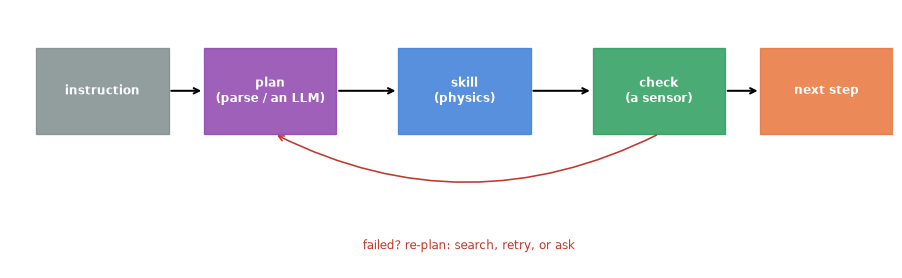

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 3.0)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(-0.3, 2.4)
boxes = [(0.3, "instruction", "#7f8c8d"), (2.2, "plan\n(parse / an LLM)", "#8e44ad"), (4.4, "skill\n(physics)", "#3b7dd8"),
         (6.6, "check\n(a sensor)", "#2a9d5c"), (8.5, "next step", "#e8743b")]
for x, label, c in boxes:
    ax.add_patch(plt.Rectangle((x, 1.1), 1.5, 0.9, color=c, alpha=0.85))
    ax.text(x + 0.75, 1.55, label, ha="center", va="center", color="w", fontsize=9, weight="bold")
for x0, x1 in ((1.8, 2.2), (3.7, 4.4), (5.9, 6.6), (8.1, 8.5)):
    ax.annotate("", xy=(x1, 1.55), xytext=(x0, 1.55), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(3.0, 1.1), xytext=(7.35, 1.1), arrowprops=dict(arrowstyle="->", lw=1.2, color="#c0392b",
            connectionstyle="arc3,rad=-0.25"))
ax.text(5.2, -0.1, "failed? re-plan: search, retry, or ask", ha="center", fontsize=9, color="#c0392b")
fig.tight_layout(); plt.show()

**Perceive → plan → act → verify.** The checks are what make it an agent
rather than a script. Without them, a plan runs to the end whatever
happens: the robot “looks at the crimson ball” while staring at the
floor, and “raises both hands” from the floor.

------------------------------------------------------------------------

## Where a language model fits

The parser is the part a large language model replaces. Given the skills
as **tools**, it writes the plan — and it already knows that crimson is
red, that “hands up” means both, and that it cannot see behind itself:

``` python
# Not run here: it needs an API key and a network connection.
import anthropic
from soc4180 import agent
client = anthropic.Anthropic()
ball = {"type": "object", "properties": {"colour": {"enum": ["red", "green", "blue", "yellow"]}}, "required": ["colour"]}
arm = {"type": "object", "properties": {"side": {"enum": ["left", "right"]}}, "required": ["side"]}
tools = [{"name": "look", "description": "Turn the waist until the named ball is centred. Verifies by colour.", "input_schema": ball},
         {"name": "search", "description": "Turn and look until the named ball is found.", "input_schema": ball},
         {"name": "raise", "description": "Raise one arm overhead. Raising both at once topples the robot.", "input_schema": arm}]
body = agent.Body(); eyes = agent.Eyes(body, "checkpoints/heatnet.pt")
messages = [{"role": "user", "content": "Face the crimson ball, then hands up."}]
while True:
    reply = client.messages.create(model="claude-opus-5", max_tokens=16000, tools=tools, messages=messages)
    messages.append({"role": "assistant", "content": reply.content})
    if reply.stop_reason != "tool_use":
        break
    results = []
    for block in reply.content:
        if block.type == "tool_use":                         # run the skill; its check is the answer
            args = block.input.get("colour", block.input.get("side"))
            r = agent.SKILLS[block.name](body, eyes, f"the {args} ball" if block.name != "raise" else args)
            results.append({"type": "tool_result", "tool_use_id": block.id, "content": r.message,
                            "is_error": not r.ok})
    messages.append({"role": "user", "content": results})    # all results in one message
```

The skills, their checks and the loop stay exactly as they are. That
split — a model that plans in words, skills that act, sensors that
verify — is how most language-driven robot systems are built today
(SayCan, 2022; Code as Policies, 2022; and the agents built on the
current models).

------------------------------------------------------------------------

## Why the checks matter more with a better planner

A keyword parser fails loudly: it cannot read “crimson”, so it stops. A
language model fails **fluently**: it writes a plausible plan for
anything, including a plan whose second step topples the robot, or a
`look` at a ball that is not there.

| failure                          | who catches it                        |
|----------------------------------|---------------------------------------|
| a word the robot cannot ground   | the colour check (`look` fails)       |
| a plan that is physically unwise | the pelvis check (`raise_both` fails) |
| the named thing is out of sight  | the colour check, then `search`       |
| a skill that “succeeds” wrongly  | nothing — unless a check measures it  |

A robot acts in the world, and some actions cannot be undone. **The
cheaper and more general the planner, the more the verification has to
carry.**

------------------------------------------------------------------------

## The course, as one stack

| layer | what we built | weeks |
|------------------------|------------------------|------------------------|
| 1 Physics | MuJoCo, MJCF, contact, a timestep that can blow up | 0–1 |
| 2 Robot model | frames, FK, the body as a tree of numbers, sensors, a camera | 2–2b, 6, 14 |
| 4 Control | IK, LIPM walking, PD servos, filters, **MPPI** | 3–6, 11 |
| 5 Learning | MDPs, PPO, rewards, scale, **robustness, imitation** | 7–10, 12–13 |
| 5 Behaviour | **pixels, words, an agent that checks its work** | 14–15 |

Every layer was *measured*: nothing on these slides is a number someone
told us. The capstone is to add one more row.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/15-language/lab_agent.py          # torch: uv sync --extra rl
uv run weeks/15-language/lab_agent.py --say "look at the red ball and raise your left hand"
```

A game: five instructions. **You edit only `instructions.py`**:
`SYNONYMS` (words the robot has never seen), `PROGRAMS` (whole plans for
a phrase), `SEARCH` (how to look for what is out of sight) and
`LOOK_GAIN`. `1`–`5` run an instruction and play it back, `G` grades all
five; `instructions.py` ships with blanks and scores 0 / 5.

| \# | Instruction | Needs |
|------------------------|------------------------|------------------------|
| 1 | “look at the green ball” | a gain that turns without falling |
| 2 | “face the crimson ball”, “look at the azure one” | two words grounded by hand |
| 3 | “raise both hands” | a plan that does not topple the robot |
| 4 | “find the yellow ball” (110° to the left) | a search that reaches it |
| 5 | look, raise, then find — one sentence | everything, in order |

------------------------------------------------------------------------

## Lab class: `ground.py`

``` bash
uv run weeks/15-language/ground.py
uv run weeks/15-language/ground.py --say "look at the green ball"
uv run weeks/15-language/ground.py --say "look at the crimson ball"
```

Renders the four-ball world, builds the vocabulary, trains HeatNet
(about 45 s), tests it on trained phrasings, new phrasings, an unknown
colour and no colour, then obeys `--say` with the waist and replays.

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | four balls, one camera | `vision.camera_model`, `render_dataset` |
| 2 | the vocabulary | `vision.Vocab`, `bag` |
| 3 | train | `vision.HeatNet`, `cross_entropy`, `cell_of`, `uv_of` |
| 4 | what it understood | `heat_to_uv`, `angles_of_uv` |
| 5 | obey | `Renderer(camera="head")`, `data.ctrl[waist]`, `mj_step`, `ball_direction` |

------------------------------------------------------------------------

## Exercises

1.  **Order matters.** Add the instruction “the ball left of the red
    one”. What does a bag of words make of it, and what would the
    network need?
2.  **A new colour.** Add a fifth, purple ball and the word “purple” to
    the templates. How many pictures does the network need to learn it?
3.  **Say “not here”.** Train HeatNet with a 257th cell meaning
    *absent*, on pictures where the named ball is behind the robot. Does
    the agent still need the colour check?
4.  **Synonyms for free.** Replace the bag of words with a pretrained
    word embedding (for instance GloVe vectors, downloaded once). Does
    “crimson” now work with no `SYNONYMS` entry?
5.  **An LLM planner.** With an API key, give the four skills to a
    language model as tools and run the five lab instructions. Which
    checks fire?

------------------------------------------------------------------------

## Capstone

Pick one layer and one number, and move it. Some that the course left
open:

- make the week-4 walker **turn**, and a student that imitates it;
- give PPO the **latency** of a real robot (week 12, exercise 3) and win
  back the margin it loses;
- a planner that also keeps the robot **where it was** after a 300 N
  shove (week 11);
- a camera that sees a ball **and a person**, and an instruction that
  uses both;
- anything else — with the number measured before and after.

Presentations in the final-exam slot.